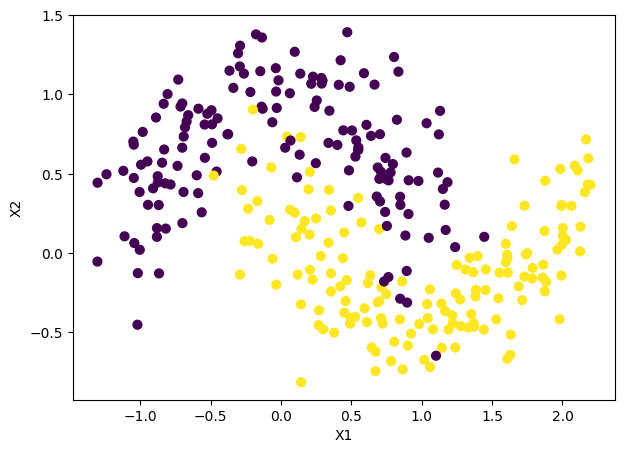

(2, 300)
(1, 300)


In [101]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate dataset
X, Y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=3
)

# Convert to Andrew Ng format
X = X.T
Y = Y.reshape(1, -1)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(
    X[0, :],
    X[1, :],
    c=Y.ravel(),
    s=40
)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

print(X.shape)
print(Y.shape)

In [102]:
#initialize parameters with random values
def initialize_parameters(layers_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * 1.0
        parameters["b" + str(l)] = np.zeros(
            (layers_dims[l], 1)
        )
    return parameters

In [103]:
#Activation functions
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [104]:
#Forward propagation
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # Layer 1
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    )

    return A3, cache

In [105]:
def compute_cost(A3, Y):

    m = Y.shape[1]

    A3 = np.clip(A3, 1e-15, 1 - 1e-15)

    cost = -(1/m) * np.sum(
        Y * np.log(A3)
        +
        (1-Y) * np.log(1-A3)
    )

    return np.squeeze(cost)

In [106]:
#Backward propagation
def backward_propagation(X, Y, cache):

    m = X.shape[1]

    (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    ) = cache

    dZ3 = A3 - Y

    dW3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(
        dZ3,
        axis=1,
        keepdims=True
    )

    dA2 = np.dot(W3.T, dZ3)

    dZ2 = dA2 * (A2 > 0)

    dW2 = (1/m) * np.dot(dZ2, A1.T)

    db2 = (1/m) * np.sum(
        dZ2,
        axis=1,
        keepdims=True
    )

    dA1 = np.dot(W2.T, dZ2)

    dZ1 = dA1 * (A1 > 0)

    dW1 = (1/m) * np.dot(dZ1, X.T)

    db1 = (1/m) * np.sum(
        dZ1,
        axis=1,
        keepdims=True
    )

    gradients = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }

    return gradients

In [108]:
def update_parameters_with_gd(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L+1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]
    return parameters

In [109]:
#Gradient function: mini batch
def random_mini_batches(X,Y,mini_batch_size=64, seed=0):
    np.random.seed(seed)
    m = X.shape[1]
    mini_batches = []

    # Shuffle (X, Y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1,m))

    inc = mini_batch_size
    
    # Partition (shuffled_X, shuffled_Y). Minus the end case.
    num_complete_minibatches = m // mini_batch_size
    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size : (k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append((mini_batch_X, mini_batch_Y))

    # Handling the end case (last mini-batch < mini_batch_size)
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size : m]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size : m]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append((mini_batch_X, mini_batch_Y))

    return mini_batches

In [110]:
# GRADED FUNCTION: initialize_velocity

def initialize_velocity(parameters):
    
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}
    
    # Initialize velocity
    for l in range(1, L + 1):
        v["dW" + str(l)] = np.zeros_like(
            parameters["W" + str(l)]
        )

        v["db" + str(l)] = np.zeros_like(
            parameters["b" + str(l)]
        )
        
        
    return v

In [111]:
# GRADED FUNCTION: update_parameters_with_momentum

def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):

    L = len(parameters) // 2 # number of layers in the neural networks
    
    # Momentum update for each parameter
    for l in range(1, L + 1):
        v["dW" + str(l)] = (
            beta * v["dW" + str(l)]
            + (1 - beta) * grads["dW" + str(l)]
        )

        v["db" + str(l)] = (
            beta * v["db" + str(l)]
            + (1 - beta) * grads["db" + str(l)]
        )

        parameters["W" + str(l)] = (
            parameters["W" + str(l)]
            - learning_rate * v["dW" + str(l)]
        )

        parameters["b" + str(l)] = (
            parameters["b" + str(l)]
            - learning_rate * v["db" + str(l)]
        )
        
    return parameters, v

In [112]:
# GRADED FUNCTION: initialize_adam

def initialize_adam(parameters) :
    
    L = len(parameters) // 2 # number of layers in the neural networks
    v = {}
    s = {}
    
    # Initialize v, s. Input: "parameters". Outputs: "v, s".
    for l in range(1, L + 1):
        v["dW" + str(l)] = np.zeros_like(
            parameters["W" + str(l)]
        )

        v["db" + str(l)] = np.zeros_like(
            parameters["b" + str(l)]
        )

        s["dW" + str(l)] = np.zeros_like(
            parameters["W" + str(l)]
        )

        s["db" + str(l)] = np.zeros_like(
            parameters["b" + str(l)]
        )
    
    return v, s

In [113]:
# GRADED FUNCTION: update_parameters_with_adam

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate = 0.01,
                                beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8):
    
    L = len(parameters) // 2                 # number of layers in the neural networks
    v_corrected = {}                         # Initializing first moment estimate, python dictionary
    s_corrected = {}                         # Initializing second moment estimate, python dictionary
    
    # Perform Adam update on all parameters
    for l in range(1, L + 1):
        
        v["dW" + str(l)] = beta1 * v["dW" + str(l)] + (1 - beta1) * grads["dW" + str(l)]

        v["db" + str(l)] = beta1 * v["db" + str(l)] + (1 - beta1) * grads["db" + str(l)]
        
        v_corrected["dW" + str(l)] = (
        v["dW" + str(l)] / (1 - beta1**t)
        )

        v_corrected["db" + str(l)] = (
        v["db" + str(l)] / (1 - beta1**t)
        )
        
        # YOUR CODE ENDS HERE
        s["dW" + str(l)] = (
        beta2 * s["dW" + str(l)]
        + (1 - beta2) * np.square(grads["dW" + str(l)])
        )

        s["db" + str(l)] = (
        beta2 * s["db" + str(l)]
        + (1 - beta2) * np.square(grads["db" + str(l)])
        )
        
        s_corrected["dW" + str(l)] = (
        s["dW" + str(l)] / (1 - beta2**t)
        )

        s_corrected["db" + str(l)] = (
        s["db" + str(l)] / (1 - beta2**t)
        )
        
        parameters["W" + str(l)] = (
        parameters["W" + str(l)]
        - learning_rate
        * v_corrected["dW" + str(l)]
        / (np.sqrt(s_corrected["dW" + str(l)]) + epsilon)
        )

        parameters["b" + str(l)] = (
        parameters["b" + str(l)]
        - learning_rate
        * v_corrected["db" + str(l)]
        / (np.sqrt(s_corrected["db" + str(l)]) + epsilon)
        )
        

    return parameters, v, s, v_corrected, s_corrected

In [114]:
def model(X, Y, layers_dims, optimizer, learning_rate = 0.0007, mini_batch_size = 64, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 5000, print_cost = True):

    L = len(layers_dims)             # number of layers in the neural networks
    costs = []                       # to keep track of the cost
    t = 0                            # initializing the counter required for Adam update
    seed = 10                        # For grading purposes, so that your "random" minibatches are the same as ours
    m = X.shape[1]                   # number of training examples
    
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize the optimizer
    if optimizer == "gd":
        pass # no initialization required for gradient descent
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
    
    # Optimization loop
    for i in range(num_epochs):
        
        # Define the random minibatches. We increment the seed to reshuffle differently the dataset after each epoch
        seed = seed + 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)
        cost_total = 0
        
        for minibatch in minibatches:

            # Select a minibatch
            (minibatch_X, minibatch_Y) = minibatch

            # Forward propagation
            a3, caches = forward_propagation(minibatch_X, parameters)

            # Compute cost and add to the cost total
            cost_total += compute_cost(a3, minibatch_Y)

            # Backward propagation
            grads = backward_propagation(minibatch_X, minibatch_Y, caches)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t = t + 1 # Adam counter
                parameters, v, s, _, _ = update_parameters_with_adam(parameters, grads, v, s,
                                                               t, learning_rate, beta1, beta2,  epsilon)
        cost_avg = cost_total / m
        
        # Print the cost every 1000 epoch
        if print_cost and i % 1000 == 0:
            print ("Cost after epoch %i: %f" %(i, cost_avg))
        if print_cost and i % 100 == 0:
            costs.append(cost_avg)
                
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('epochs (per 100)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    return parameters

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X.T,
    Y.flatten(),
    test_size=0.2,
    random_state=42
)

X_train = X_train.T
X_test = X_test.T

Y_train = Y_train.reshape(1, -1)
Y_test = Y_test.reshape(1, -1)

In [116]:
layers_dims = [X.shape[0], 20, 3, 1]

In [117]:
def predict(X, Y, parameters):

    A3, _ = forward_propagation(X, parameters)

    predictions = (A3 > 0.5).astype(int)

    accuracy = np.mean(predictions == Y) * 100

    print("Accuracy: {:.2f}%".format(accuracy))

    return predictions

In [118]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, Y):

    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1

    h = 0.01

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.contourf(
        xx,
        yy,
        Z,
        cmap=plt.cm.Spectral,
        alpha=0.5
    )

    plt.scatter(
        X[0,:],
        X[1,:],
        c=Y.flatten(),
        cmap=plt.cm.Spectral,
        edgecolors="k"
    )

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.show()

In [119]:
def predict_dec(parameters, X):
    a3, _ = forward_propagation(X, parameters)

    predictions = (a3 > 0.5)

    return predictions

Cost after epoch 0: 0.009091
Cost after epoch 1000: 0.005347
Cost after epoch 2000: 0.005039
Cost after epoch 3000: 0.004868
Cost after epoch 4000: 0.004643


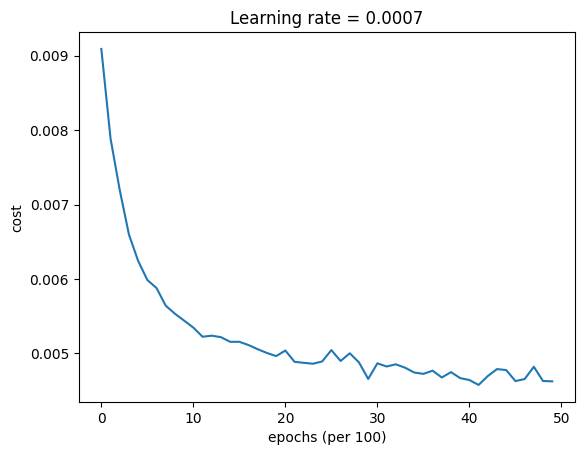

Accuracy: 87.08%


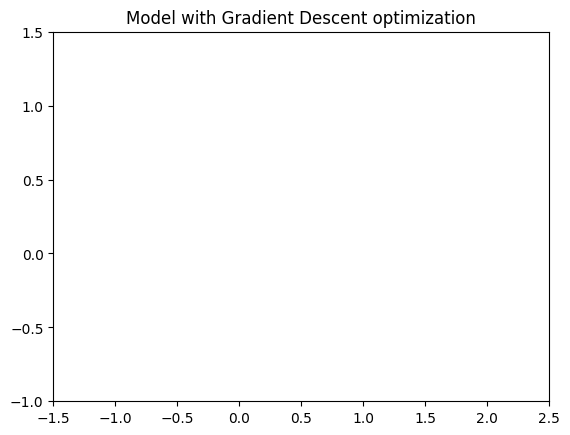

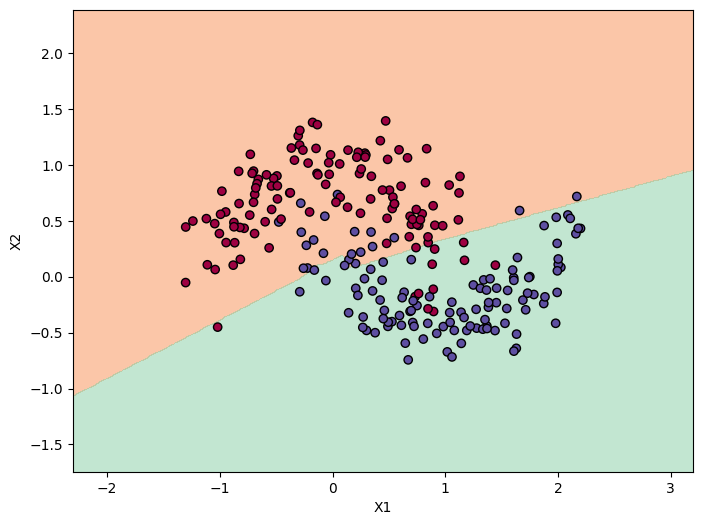

In [120]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "gd")

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

Cost after epoch 0: 0.009096
Cost after epoch 1000: 0.005347
Cost after epoch 2000: 0.005039
Cost after epoch 3000: 0.004867
Cost after epoch 4000: 0.004643


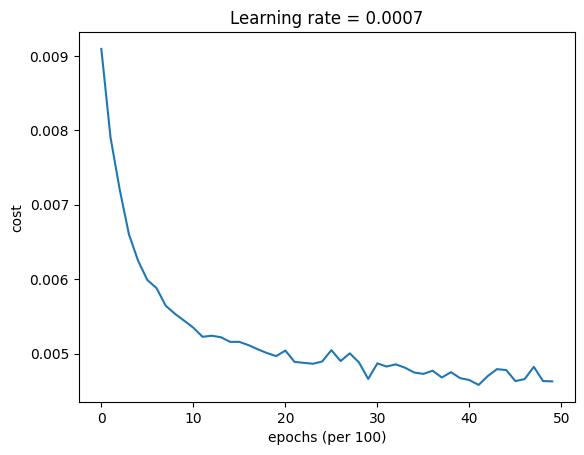

Accuracy: 87.08%


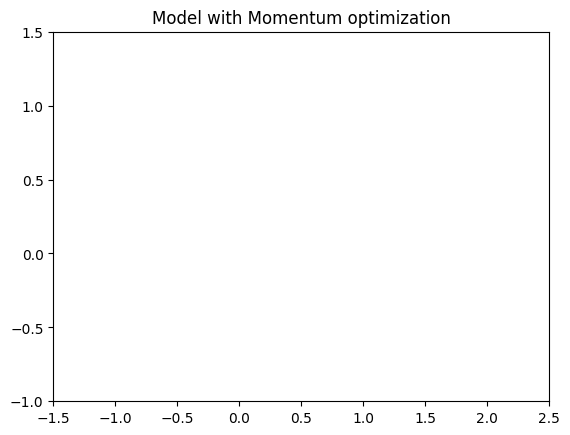

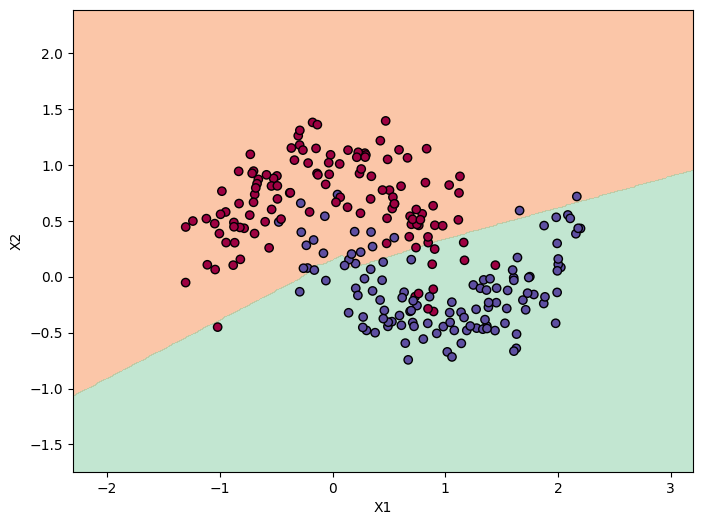

In [121]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, beta = 0.9, optimizer = "momentum")

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Momentum optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

Cost after epoch 0: 0.009050
Cost after epoch 1000: 0.001765
Cost after epoch 2000: 0.001547
Cost after epoch 3000: 0.001487
Cost after epoch 4000: 0.001359


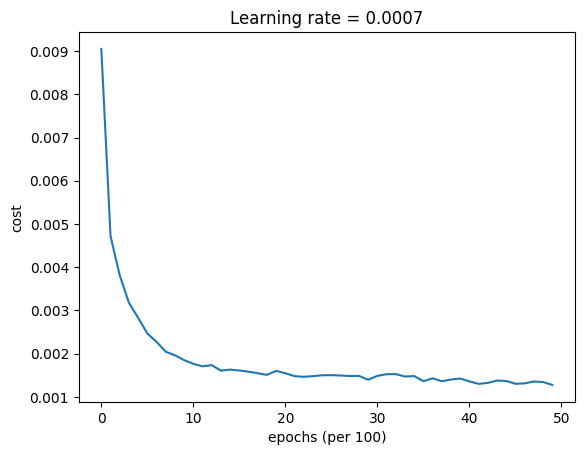

Accuracy: 96.67%


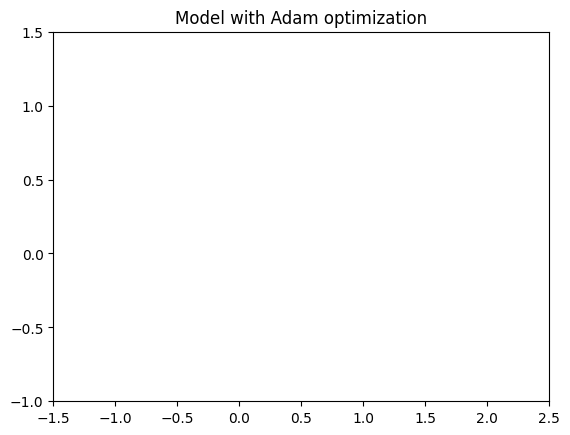

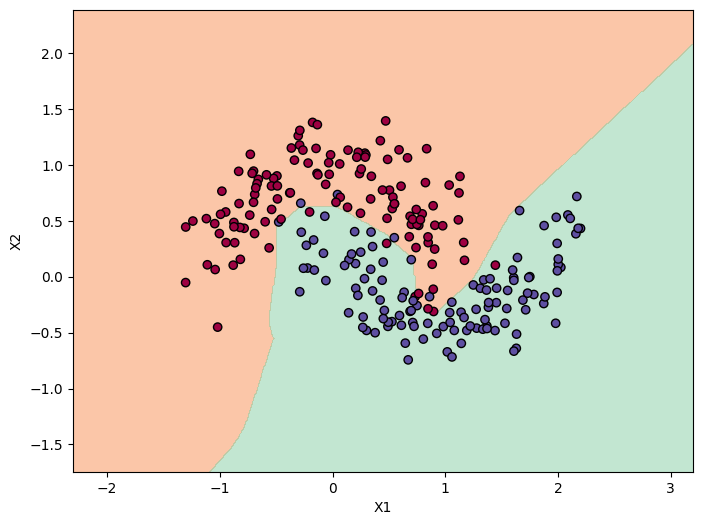

In [122]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "adam")

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Adam optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

In [123]:
predictions = predict(X_train, Y_train, parameters)

print(np.unique(predictions, return_counts=True))
print(np.mean(Y_train))

Accuracy: 96.67%
(array([0, 1]), array([121, 119]))
0.49583333333333335


# Learning Rate Decay

In [124]:
def model(X, Y, layers_dims, optimizer, learning_rate = 0.0007, mini_batch_size = 64, beta = 0.9,
          beta1 = 0.9, beta2 = 0.999,  epsilon = 1e-8, num_epochs = 5000, print_cost = True, decay=None, decay_rate=1):

    L = len(layers_dims)             # number of layers in the neural networks
    costs = []                       # to keep track of the cost
    t = 0                            # initializing the counter required for Adam update
    seed = 10                        # For grading purposes, so that your "random" minibatches are the same as ours
    m = X.shape[1]                   # number of training examples
    lr_rates = []
    learning_rate0 = learning_rate   # the original learning rate
    
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize the optimizer
    if optimizer == "gd":
        pass # no initialization required for gradient descent
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
    
    # Optimization loop
    for i in range(num_epochs):
        
        # Define the random minibatches. We increment the seed to reshuffle differently the dataset after each epoch
        seed = seed + 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)
        cost_total = 0
        
        for minibatch in minibatches:

            # Select a minibatch
            (minibatch_X, minibatch_Y) = minibatch

            # Forward propagation
            a3, caches = forward_propagation(minibatch_X, parameters)

            # Compute cost and add to the cost total
            cost_total += compute_cost(a3, minibatch_Y)

            # Backward propagation
            grads = backward_propagation(minibatch_X, minibatch_Y, caches)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t = t + 1 # Adam counter
                parameters, v, s, _, _ = update_parameters_with_adam(parameters, grads, v, s,
                                                               t, learning_rate, beta1, beta2,  epsilon)
        cost_avg = cost_total / m
        if decay:
            learning_rate = decay(learning_rate0, i, decay_rate)
        # Print the cost every 1000 epoch
        if print_cost and i % 1000 == 0:
            print ("Cost after epoch %i: %f" %(i, cost_avg))
            if decay:
                print("learning rate after epoch %i: %f"%(i, learning_rate))
        if print_cost and i % 100 == 0:
            costs.append(cost_avg)
                
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('epochs (per 100)')
    plt.title("Learning rate = " + str(learning_rate))
    plt.show()

    return parameters

In [125]:
# GRADED FUNCTION: update_lr

def update_lr(learning_rate0, epoch_num, decay_rate):
    
    learning_rate = (
        learning_rate0
        / (1 + decay_rate * epoch_num)
    )
    return learning_rate

Cost after epoch 0: 0.008506
learning rate after epoch 0: 0.100000
Cost after epoch 1000: 0.005214
learning rate after epoch 1000: 0.000100
Cost after epoch 2000: 0.005224
learning rate after epoch 2000: 0.000050
Cost after epoch 3000: 0.005159
learning rate after epoch 3000: 0.000033
Cost after epoch 4000: 0.005041
learning rate after epoch 4000: 0.000025


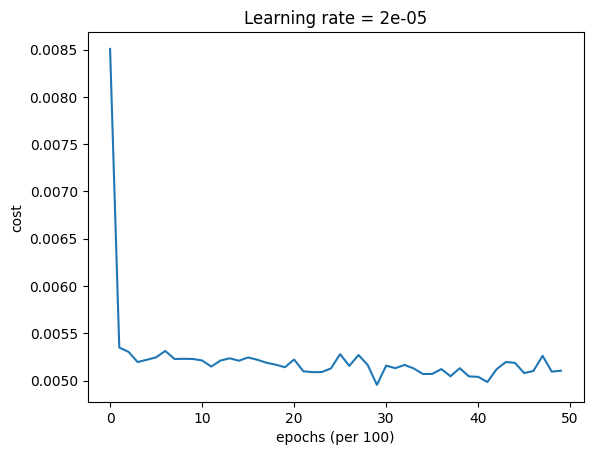

Accuracy: 86.25%


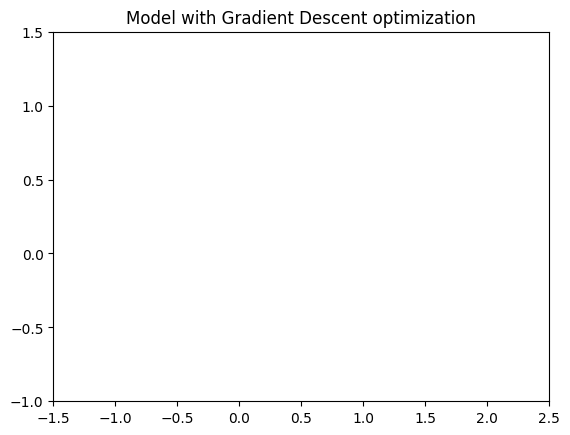

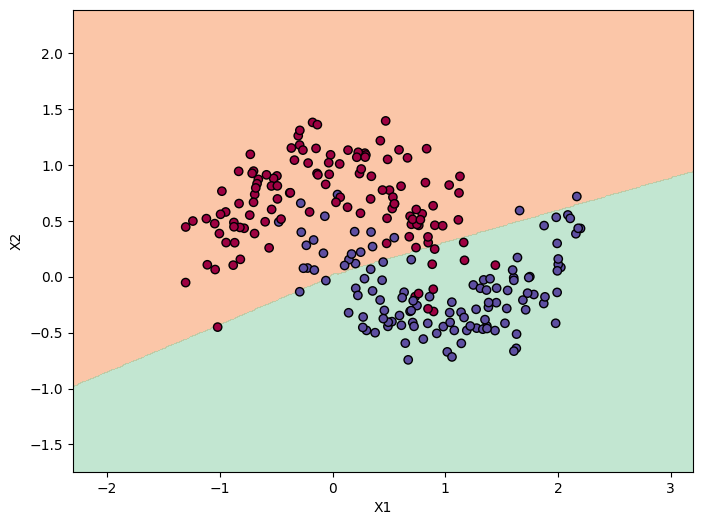

In [126]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "gd", learning_rate = 0.1, num_epochs=5000, decay=update_lr)

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

In [127]:
# GRADED FUNCTION: schedule_lr_decay

def schedule_lr_decay(learning_rate0, epoch_num, decay_rate, time_interval=1000):
    learning_rate = (
        learning_rate0
        /
        (
            1
            + decay_rate
            * np.floor(epoch_num / time_interval)
        )
    )
    return learning_rate

Cost after epoch 0: 0.008506
learning rate after epoch 0: 0.100000
Cost after epoch 1000: 0.001788
learning rate after epoch 1000: 0.050000
Cost after epoch 2000: 0.001573
learning rate after epoch 2000: 0.033333
Cost after epoch 3000: 0.001548
learning rate after epoch 3000: 0.025000
Cost after epoch 4000: 0.001478
learning rate after epoch 4000: 0.020000


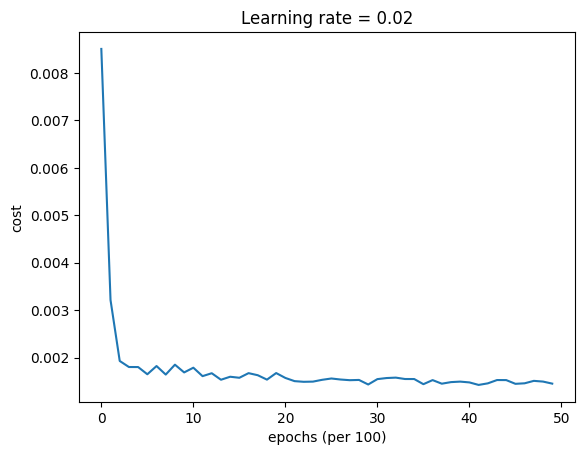

Accuracy: 95.83%


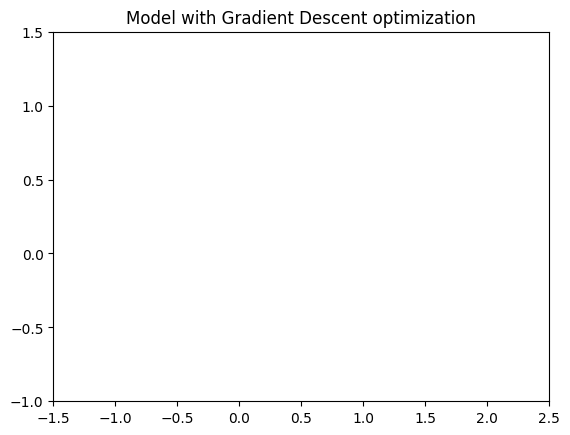

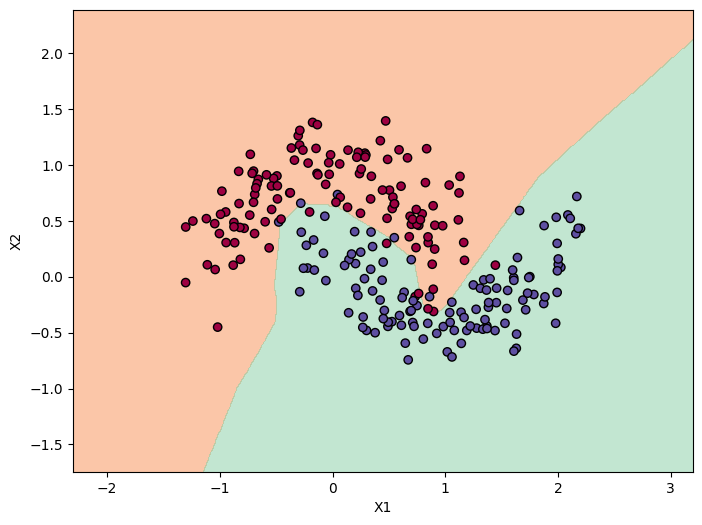

In [128]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "gd", learning_rate = 0.1, num_epochs=5000, decay=schedule_lr_decay)

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

Cost after epoch 0: 0.008973
learning rate after epoch 0: 0.100000
Cost after epoch 1000: 0.001593
learning rate after epoch 1000: 0.050000
Cost after epoch 2000: 0.001426
learning rate after epoch 2000: 0.033333
Cost after epoch 3000: 0.001368
learning rate after epoch 3000: 0.025000
Cost after epoch 4000: 0.001326
learning rate after epoch 4000: 0.020000


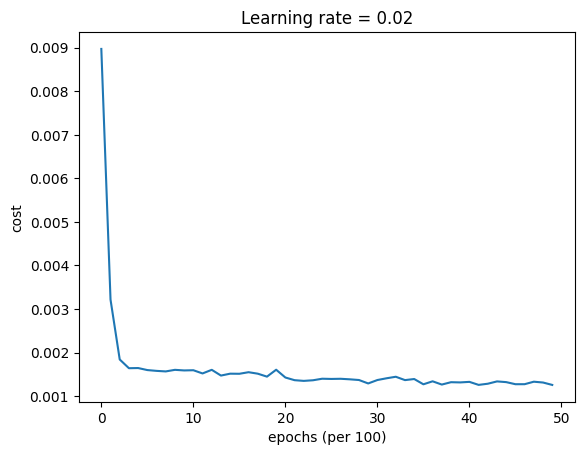

Accuracy: 95.83%


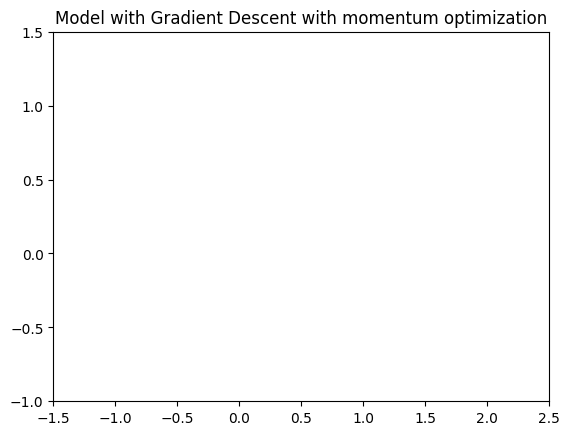

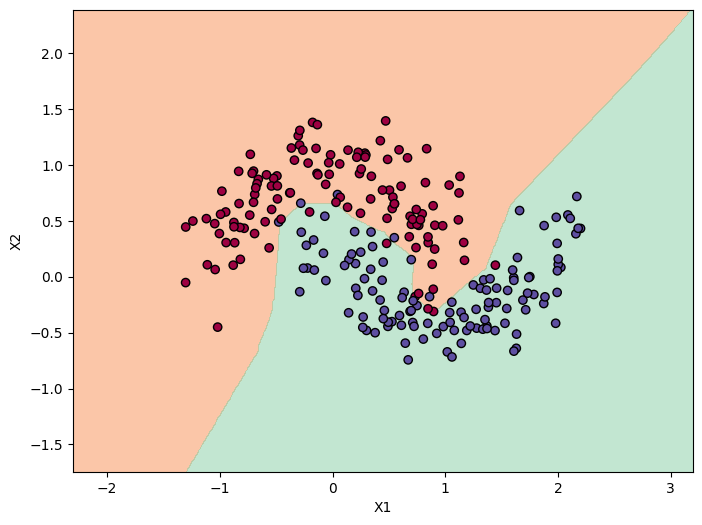

In [129]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "momentum", learning_rate = 0.1, num_epochs=5000, decay=schedule_lr_decay)

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Gradient Descent with momentum optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)

Cost after epoch 0: 0.008547
learning rate after epoch 0: 0.010000
Cost after epoch 1000: 0.001333
learning rate after epoch 1000: 0.005000
Cost after epoch 2000: 0.000954
learning rate after epoch 2000: 0.003333
Cost after epoch 3000: 0.000866
learning rate after epoch 3000: 0.002500
Cost after epoch 4000: 0.000793
learning rate after epoch 4000: 0.002000


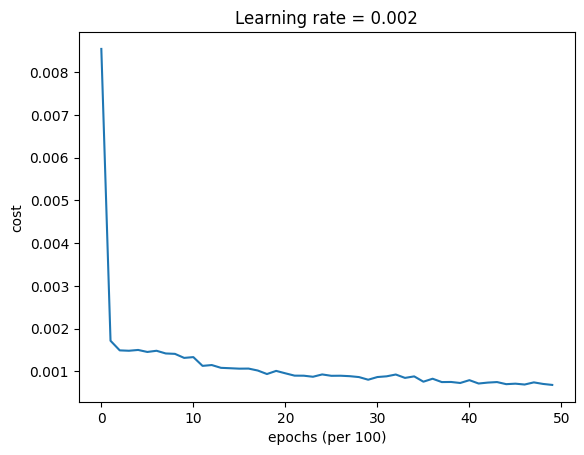

Accuracy: 97.92%


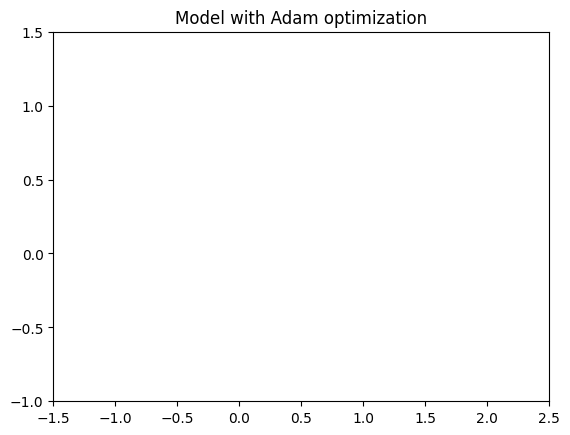

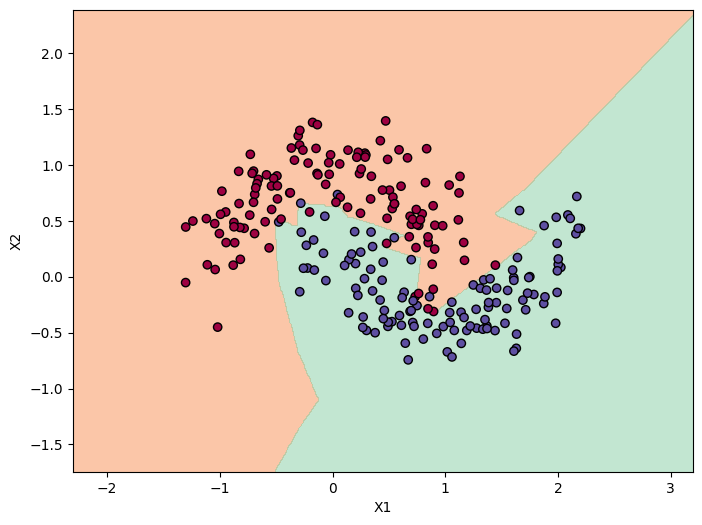

In [130]:
# train 3-layer model
layers_dims = [X.shape[0], 20, 3, 1]
parameters = model(X_train, Y_train, layers_dims, optimizer = "adam", learning_rate = 0.01, num_epochs=5000, decay=schedule_lr_decay)

# Predict
predictions = predict(X_train, Y_train, parameters)

# Plot decision boundary
plt.title("Model with Adam optimization")
axes = plt.gca()
axes.set_xlim([-1.5,2.5])
axes.set_ylim([-1,1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), X_train, Y_train)